In [2]:
import pandas as pd
import numpy as np
from final_project_d200.data import read_data
from final_project_d200.preprocessing import add_features_responders, downsample, NUM_FEATURES, CAT_FEATURES, TARGET_COL, TARGET_COLS_PRE
from final_project_d200.modeling import train_mdn, pretrain_mdn, run_mdn_config
from final_project_d200.evaluation import (
    compute_mdn_nll, compute_mean_crps_mdn, get_predicted_parameters, 
    compute_pretrain_loss_components, compute_pretrain_loss,
    read_grid_search_results, write_grid_search_results
)
from final_project_d200.plotting import (
    plot_predicted_parameters, plot_pit, plot_mdns_vs_gbt_vol_medoid,
    plot_train_and_val_loss
)
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Any
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from collections import OrderedDict
from torch.utils.data import DataLoader, TensorDataset
import scipy.stats as stats
import itertools
import copy
from pathlib import Path

### Load Data

In [3]:
df = read_data("btc_with_gbt_preds")
df.head()

,split,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,...,quote_volume_pct_change,past_180m_vol,past_720m_vol,past_1440m_vol,past_10080m_vol,past_43200m_vol,past_50m_span_ewm_vol,past_50m_vol_pct_change,event_code,gbt_future_30m_mean_sq_ret_pred
43200,train,2023-11-30 19:00:00 ET,37723.97,37744.72,37722.73,37738.91,34.53633,2023-11-30 19:00:59 ET,1.303099e+06,1119,...,0.061855,0.175818,0.277380,0.260482,0.320534,0.412684,0.185884,-0.099284,NONE,9.346555e-08
43201,train,2023-11-30 19:01:00 ET,37738.91,37738.91,37723.72,37723.72,12.71120,2023-11-30 19:01:59 ET,4.796356e+05,667,...,0.096078,0.176291,0.277533,0.260587,0.320546,0.412684,0.190869,-0.081458,NONE,9.226979e-08
43202,train,2023-11-30 19:02:00 ET,37723.72,37723.73,37699.57,37699.57,33.22694,2023-11-30 19:02:59 ET,1.252938e+06,956,...,0.012599,0.177571,0.277139,0.260694,0.320557,0.412678,0.195810,-0.067271,NONE,9.546778e-08
43203,train,2023-11-30 19:03:00 ET,37699.58,37699.58,37699.57,37699.57,6.89939,2023-11-30 19:03:59 ET,2.601041e+05,341,...,0.093164,0.180828,0.277650,0.260867,0.320590,0.412682,0.212787,-0.013871,NONE,1.121719e-07
43204,train,2023-11-30 19:04:00 ET,37699.57,37699.58,37688.27,37688.35,14.22495,2023-11-30 19:04:59 ET,5.362203e+05,476,...,-0.004551,0.179834,0.276626,0.260862,0.320585,0.412672,0.208573,-0.042709,NONE,9.886201e-08


Note that data is pre-split into train/val/test, and we already have predictions from my best GBT model. Plenty of preprocessing has already been done.

### Part 2: Mixed Density Network
Now, I will construct a feature set and training/validation pipeline to create the best MDN to predict future distributions of returns.

In [4]:
df = read_data("btc_with_gbt_preds")
df = add_features_responders(df)

In [5]:
cols = NUM_FEATURES + CAT_FEATURES + [TARGET_COL] + TARGET_COLS_PRE


df_train = downsample(df.query("split == 'train'"), set([0, 30])).dropna(subset=cols)
df_val = downsample(df.query("split == 'val'"), set([0, 30])).dropna(subset=cols)
df_test = downsample(df.query("split == 'test'"), set([0, 30])).dropna(subset=cols)

# Make numerical feature tensors
X_train_num = df_train[NUM_FEATURES].to_numpy(dtype=np.float32)
X_val_num = df_val[NUM_FEATURES].to_numpy(dtype=np.float32)
X_test_num = df_test[NUM_FEATURES].to_numpy(dtype=np.float32)

# Future 30m return targets
y_train = df_train[TARGET_COL].to_numpy(dtype=np.float32)
y_val = df_val[TARGET_COL].to_numpy(dtype=np.float32)
y_test = df_test[TARGET_COL].to_numpy(dtype=np.float32)

# Extract pretrain targets, to be used for transfer learning
y_train_pre = df_train[TARGET_COLS_PRE].to_numpy(dtype=np.float32)
y_val_pre = df_val[TARGET_COLS_PRE].to_numpy(dtype=np.float32)

# Scale features, train scaler on train set
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_num)
X_val_num = scaler.transform(X_val_num)
X_test_num = scaler.transform(X_test_num)

X_train_num = torch.tensor(X_train_num, dtype=torch.float32)
X_val_num = torch.tensor(X_val_num, dtype=torch.float32)
X_test_num = torch.tensor(X_test_num, dtype=torch.float32)

# Make categorical feature tensors
X_train_cat = df_train[CAT_FEATURES]
X_val_cat = df_val[CAT_FEATURES]
X_test_cat = df_test[CAT_FEATURES]

# Encode categoricals
encoder = OneHotEncoder(sparse_output=False, handle_unknown="error")
X_train_cat = encoder.fit_transform(X_train_cat)
X_val_cat = encoder.transform(X_val_cat)
X_test_cat = encoder.transform(X_test_cat)

X_train_cat = torch.tensor(X_train_cat, dtype=torch.float32)
X_val_cat = torch.tensor(X_val_cat, dtype=torch.float32)
X_test_cat = torch.tensor(X_test_cat, dtype=torch.float32)

# Combine categoricals + turn into tensors
X_train = torch.cat([X_train_num, X_train_cat], dim=1)
X_val = torch.cat([X_val_num, X_val_cat], dim=1)
X_test = torch.cat([X_test_num, X_test_cat], dim=1)

# Convert targets to tensors
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

y_train_pre = torch.tensor(y_train_pre, dtype=torch.float32)
y_val_pre = torch.tensor(y_val_pre, dtype=torch.float32)

# Turn into TensorDataset for DataLoader
train_data = TensorDataset(X_train, y_train)
val_data = TensorDataset(X_val, y_val)
test_data = TensorDataset(X_test, y_test)

# Do the same for transfer data
train_data_pre = TensorDataset(X_train, y_train_pre)
val_data_pre = TensorDataset(X_val, y_val_pre)

device = "cuda" if torch.cuda.is_available() else "cpu"

First model: hidden layers directly to output layer for mixed density parameters.

In [6]:
# Create MDN

class MDN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, hidden_layers=2, n_components=3, mean_zero=False,
                 dropout=0.0, feature_dropout=0.0):
        super().__init__()

        hidden_layer_list = []
        for i in range(hidden_layers):
            hidden_layer_list.append((f"linear{i}", nn.Linear(hidden_dim, hidden_dim)))
            hidden_layer_list.append((f"relu{i}", nn.ReLU()))
            hidden_layer_list.append((f"dropout{i}", nn.Dropout(dropout)))


        self.net = nn.Sequential(OrderedDict([
            ("feature_dropout", nn.Dropout(feature_dropout)),
            ("input", nn.Linear(input_dim, hidden_dim)),
            ("relu_input", nn.ReLU()),
            ("dropout_input", nn.Dropout(dropout))] + hidden_layer_list
        ))

        self.mixture_weights = nn.Linear(hidden_dim, n_components)
        if not mean_zero:
            self.means = nn.Linear(hidden_dim, n_components)
        else:
            self.means = None
        self.scales = nn.Linear(hidden_dim, n_components)

        self.n_components = n_components

    def forward(self, x):
        out = self.net(x)

        mixture_weights = self.mixture_weights(out)
        mixture_probs = F.softmax(mixture_weights, dim=1)
        
        if self.means is not None:
            uncentered_means = self.means(out)
            weighted_mean = (uncentered_means * mixture_probs).sum(dim=1, keepdim=True)
            means = uncentered_means - weighted_mean
        else:
            means = torch.zeros(out.shape[0], self.n_components, device=out.device)

        scales = F.softplus(self.scales(out)) + 1e-6

        return mixture_probs, means, scales
    
def build_mdn(params: dict[str, Any], input_dim: int) -> MDN:
    """
    Function used to build MDN in grid search loops.

    Parameters
    ----------
    params : dict[str, Any]
        Dictionary containing all necessary hyperparams.
    input_dim : int
        Input dimension to MDN.

    Returns
    -------
    MDN
        Instantiated MDN.
    """
    return MDN(
        input_dim=input_dim,
        hidden_dim=params["hidden_dim"],
        hidden_layers=params["hidden_layers"],
        n_components=params["n_components"],
        mean_zero=params["mean_zero"],
        dropout=params["dropout"],
        feature_dropout=params["feature_dropout"],
    )

In [8]:
param_grid = {
    "batch_size": [128],
    "hidden_dim": [16],
    "hidden_layers": [3],
    "n_components": [5],
    "mean_zero": [True],
    "dropout": [0],
    "feature_dropout": [0.1],
    "lr": [1e-4],
    "weight_decay": [0],
    "lambda_mean": [0]
}

keys = param_grid.keys()
values = param_grid.values()

rows = []
combos = list(itertools.product(*values))

for i, combo in enumerate(combos, start=1):

    params = dict(zip(keys, combo))
    print(f"testing {params}, {i}/{len(combos)}")

    best_val_nll, avg_train_nll_near_optimum, avg_val_nll_near_optimum, avg_val_crps_near_optimum, num_epochs = run_mdn_config(
        build_mdn, params, X_train, 
        y_train, X_val, y_val, epochs=20
    )

    rows.append({
        "params": tuple(sorted(params.items())),
        "best_val_nll": best_val_nll,
        "avg_train_nll_near_optimum": avg_train_nll_near_optimum,
        "avg_val_nll_near_optimum": avg_val_nll_near_optimum,
        "avg_val_crps_near_optimum": avg_val_crps_near_optimum,
    })

    print(f"Best Val NLL: {best_val_nll}, took {num_epochs} epochs")

df_results = pd.DataFrame(rows)


testing {'batch_size': 128, 'hidden_dim': 16, 'hidden_layers': 3, 'n_components': 5, 'mean_zero': True, 'dropout': 0, 'feature_dropout': 0.1, 'lr': 0.0001, 'weight_decay': 0, 'lambda_mean': 0}, 1/1
Best Val NLL: -4.528125286102295, took 20 epochs


In [9]:
pd.options.display.max_colwidth = None
display(df_results.sort_values(by="best_val_nll", ascending=True))

,params,best_val_nll,avg_train_nll_near_optimum,avg_val_nll_near_optimum,avg_val_crps_near_optimum
0,"((batch_size, 128), (dropout, 0), (feature_dropout, 0.1), (hidden_dim, 16), (hidden_layers, 3), (lambda_mean, 0), (lr, 0.0001), (mean_zero, True), (n_components, 5), (weight_decay, 0))",-4.528125,-4.332555,-4.505477,0.001659


In [7]:
write_grid_search_results(df_results)


Appended results to hyperparams.csv


,params,best_val_nll,avg_val_nll_last_20,avg_train_nll_last_20,avg_val_crps_last_20
0,"((batch_size, 128), (dropout, 0), (feature_dropout, 0.1), (hidden_dim, 16), (hidden_layers, 3), (lambda_mean, 0), (lr, 0.0001), (mean_zero, True), (n_components, 5), (weight_decay, 0))",-4.571615,-4.567982,-4.413198,0.001611


In [46]:
df_all_results = read_grid_search_results()

pd.options.display.max_colwidth = None
display(df_all_results.sort_values(by="avg_val_nll_last_20", ascending=True))

,params,best_val_nll,avg_val_nll_last_20,avg_train_nll_last_20,avg_val_crps_last_20
25,"(('batch_size', 128), ('dropout', 0), ('feature_dropout', 0.1), ('hidden_dim', 16), ('hidden_layers', 3), ('lambda_mean', 0), ('lr', 0.0001), ('mean_zero', True), ('n_components', 5), ('weight_decay', 0))",-4.573200,-4.571742,-4.413239,0.001610
24,"(('batch_size', 128), ('dropout', 0), ('feature_dropout', 0.1), ('hidden_dim', 16), ('hidden_layers', 3), ('lambda_mean', 0), ('lr', 0.0001), ('mean_zero', True), ('n_components', 5), ('weight_decay', 0))",-4.573100,-4.571230,-4.410264,0.001609
16,"(('batch_size', 32), ('dropout', 0), ('feature_dropout', 0.1), ('hidden_dim', 8), ('hidden_layers', 4), ('lambda_mean', 0), ('lr', 0.0001), ('mean_zero', True), ('n_components', 5), ('weight_decay', 0))",-4.572700,-4.570869,-4.411037,0.001610
5,"(('batch_size', 32), ('dropout', 0), ('feature_dropout', 0.1), ('hidden_dim', 16), ('hidden_layers', 3), ('lambda_mean', 0), ('lr', 0.0001), ('mean_zero', True), ('n_components', 5), ('weight_decay', 0))",-4.573600,-4.570648,-4.413942,0.001609
30,"(('batch_size', 128), ('dropout', 0), ('feature_dropout', 0.1), ('hidden_dim', 16), ('hidden_layers', 3), ('lambda_mean', 0), ('lr', 0.0001), ('mean_zero', True), ('n_components', 5), ('weight_decay', 0))",-4.571721,-4.570474,-4.416370,0.001610
27,"(('batch_size', 128), ('dropout', 0), ('feature_dropout', 0.1), ('hidden_dim', 16), ('hidden_layers', 3), ('lambda_mean', 0), ('lr', 0.0001), ('mean_zero', True), ('n_components', 5), ('weight_decay', 0))",-4.572300,-4.570264,-4.414996,0.001610
20,"(('batch_size', 32), ('dropout', 0), ('feature_dropout', 0.1), ('hidden_dim', 8), ('hidden_layers', 5), ('lambda_mean', 0), ('lr', 0.0001), ('mean_zero', True), ('n_components', 5), ('weight_decay', 0))",-4.571700,-4.570139,-4.410198,0.001609
1,"(('batch_size', 32), ('dropout', 0), ('feature_dropout', 0.05), ('hidden_dim', 16), ('hidden_layers', 3), ('lambda_mean', 0), ('lr', 0.0001), ('mean_zero', True), ('n_components', 5), ('weight_decay', 0))",-4.572100,-4.569923,-4.415483,0.001611
22,"(('batch_size', 32), ('dropout', 0), ('feature_dropout', 0.1), ('hidden_dim', 16), ('hidden_layers', 3), ('lambda_mean', 0), ('lr', 0.0001), ('mean_zero', True), ('n_components', 5), ('weight_decay', 0))",-4.573200,-4.569559,-4.413073,0.001611
19,"(('batch_size', 32), ('dropout', 0), ('feature_dropout', 0.1), ('hidden_dim', 4), ('hidden_layers', 5), ('lambda_mean', 0), ('lr', 0.0001), ('mean_zero', True), ('n_components', 5), ('weight_decay', 0))",-4.571500,-4.569523,-4.406781,0.001609


Did plenty of grid search: shallow nets 3-4 deep performed best. Settled on component selection for 3x16, 4 or 5 components performed best. Below is a full training loop, written in its entirety.

In [6]:
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)

model = MDN(
    input_dim=X_train.shape[1],
    hidden_dim=16,
    hidden_layers=3,
    n_components=5,
    mean_zero=True,
    feature_dropout=0.1
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=0)

epochs = 300
early_stopping_patience = 100

results = []
best_val_nll = np.inf
last_improvement = 0
best_state_dict = None

print_frequency = 20

for t in range(1, epochs + 1):
    epoch_loss = train_mdn(model, train_loader, optimizer)
    epoch_train_nll = compute_mdn_nll(model, train_loader)
    epoch_val_nll = compute_mdn_nll(model, val_loader)
    epoch_val_crps = compute_mean_crps_mdn(model, val_loader)

    if epoch_val_nll < best_val_nll:
        best_val_nll = epoch_val_nll
        last_improvement = t
        best_state_dict = copy.deepcopy(model.state_dict())

    if (t % print_frequency) == 0:
        print(f"Epoch {t}/{epochs}\n-------------------------------")
        print(f"Loss: {epoch_loss:.2f}, training nll: {epoch_train_nll}, val nll: {epoch_val_nll}, val crps: {epoch_val_crps}\n")

    results.append([epoch_loss, epoch_train_nll, epoch_val_nll, epoch_val_crps])
    
    if t - last_improvement >= early_stopping_patience:
        break

best_idx = max(0, last_improvement - 1)

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

results = np.array(results)
val_nlls = results[:, 2]
left = max(0, best_idx - 10)
right = min(len(val_nlls), best_idx + 3)
local_mean_val_nll = float(np.mean(val_nlls[left:right]))
print(f"Best val nll: {best_val_nll}, local mean vall nll: {local_mean_val_nll:.6f}")


Epoch 20/300
-------------------------------
Loss: -4.31, training nll: -4.367194175720215, val nll: -4.536890983581543, val crps: 0.0016357098147488864

Epoch 40/300
-------------------------------
Loss: -4.36, training nll: -4.394161701202393, val nll: -4.56271505355835, val crps: 0.0016136135386375502

Epoch 60/300
-------------------------------
Loss: -4.38, training nll: -4.401076793670654, val nll: -4.566797256469727, val crps: 0.0016113634304898454

Epoch 80/300
-------------------------------
Loss: -4.39, training nll: -4.40463924407959, val nll: -4.567813873291016, val crps: 0.0016107984292131417

Epoch 100/300
-------------------------------
Loss: -4.39, training nll: -4.407861232757568, val nll: -4.569536209106445, val crps: 0.0016100798346220403

Epoch 120/300
-------------------------------
Loss: -4.40, training nll: -4.406888961791992, val nll: -4.566224098205566, val crps: 0.0016114222582354822

Epoch 140/300
-------------------------------
Loss: -4.40, training nll: -4.

In [ ]:
torch.save(model.state_dict(), "../results/original_model.pt")

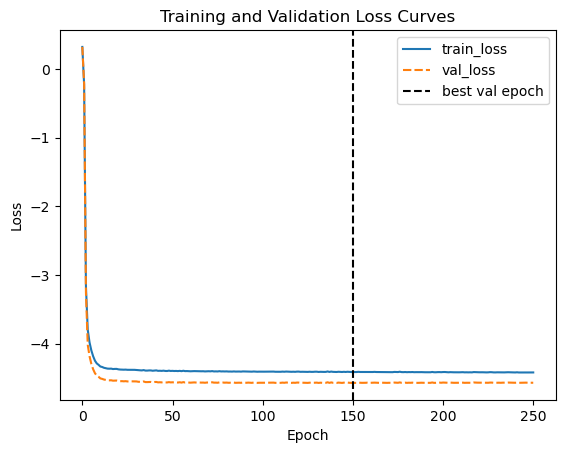

In [7]:
ax = plot_train_and_val_loss(np.array(results))

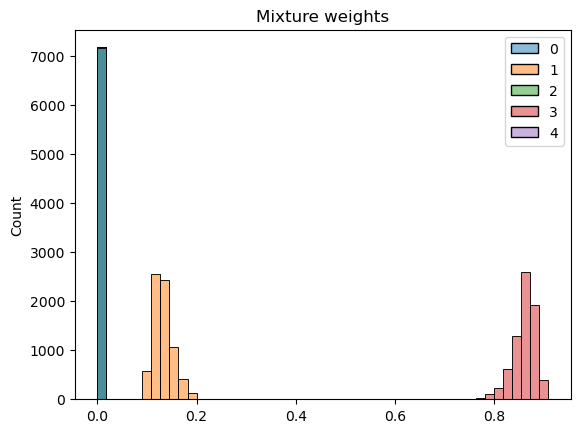

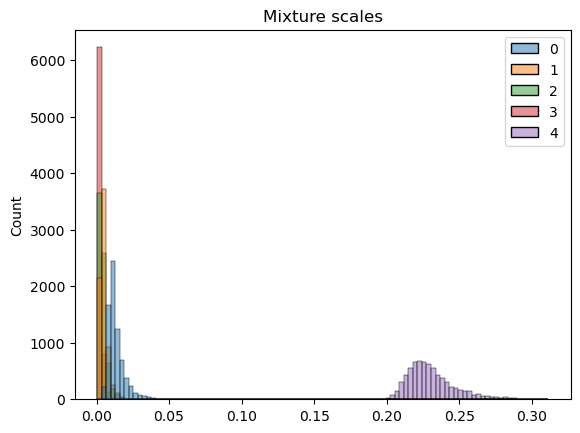

In [8]:
val_weights, val_means, val_scales = (p.numpy() for p in get_predicted_parameters(model, val_loader))
ax = sns.histplot(val_weights, bins=50)
ax.set_title("Mixture weights")
plt.show()

# ax = sns.histplot(val_means, bins=50)
# ax.set_title("Mixture means")
# plt.show()

ax = sns.histplot(val_scales, bins=100)
ax.set_title("Mixture scales")
plt.show()

### Transfer Learning

In [7]:
class MDNBackbone(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, hidden_layers=2, dropout=0.0, feature_dropout=0.0):
        super().__init__()

        hidden_layer_list = []
        for i in range(hidden_layers):
            hidden_layer_list.append((f"linear{i}", nn.Linear(hidden_dim, hidden_dim)))
            hidden_layer_list.append((f"relu{i}", nn.ReLU()))
            hidden_layer_list.append((f"dropout{i}", nn.Dropout(dropout)))


        self.net = nn.Sequential(OrderedDict([
            ("feature_dropout", nn.Dropout(feature_dropout)),
            ("input", nn.Linear(input_dim, hidden_dim)),
            ("relu_input", nn.ReLU()),
            ("dropout_input", nn.Dropout(dropout))] + hidden_layer_list
        ))

        self.hidden_dim = hidden_dim

    def forward(self, x):
        return self.net(x)
    
    
class MDNPretrain(nn.Module):
    def __init__(self, backbone,):
        super().__init__()
        self.backbone = backbone
        hidden_dim = backbone.hidden_dim

        self.vol_5_prediction = nn.Linear(hidden_dim, 1)
        self.vol_15_prediction = nn.Linear(hidden_dim, 1)
        self.vol_30_prediction = nn.Linear(hidden_dim, 1)
        self.mean_abs_30_prediction = nn.Linear(hidden_dim, 1)
        self.move_direction = nn.Linear(hidden_dim, 3)

    def forward(self, x):
        x_backbone = self.backbone(x)

        return (self.vol_5_prediction(x_backbone), self.vol_15_prediction(x_backbone),
                self.vol_30_prediction(x_backbone), self.mean_abs_30_prediction(x_backbone),
                self.move_direction(x_backbone))


class MDNFinalLayer(nn.Module):
    def __init__(self, backbone, n_components=3, mean_zero=True):
        super().__init__()
        self.backbone = backbone
        self.hidden_dim = backbone.hidden_dim

        self.mixture_weights = nn.Linear(self.hidden_dim, n_components)
        if not mean_zero:
            self.means = nn.Linear(self.hidden_dim, n_components)
        else:
            self.means = None
        self.scales = nn.Linear(self.hidden_dim, n_components)

        self.n_components = n_components

    def forward(self, x):
        out = self.backbone(x)

        mixture_weights = self.mixture_weights(out)
        mixture_probs = F.softmax(mixture_weights, dim=1)

        if self.means is not None:
            uncentered_means = self.means(out)
            weighted_mean = (uncentered_means * mixture_probs).sum(dim=1, keepdim=True)
            means = uncentered_means - weighted_mean
        else:
            means = torch.zeros(out.shape[0], self.n_components, device=out.device)

        scales = F.softplus(self.scales(out)) + 1e-6

        return mixture_probs, means, scales

In [86]:
train_loader_pre = DataLoader(train_data_pre, batch_size=256, shuffle=True)
val_loader_pre = DataLoader(val_data_pre, batch_size=256, shuffle=False)

backbone = MDNBackbone(
    input_dim=X_train.shape[1],
    hidden_dim=16,
    hidden_layers=3,
    feature_dropout=0.05
)

pretrain_model = MDNPretrain(
    backbone=backbone
)

optimizer = torch.optim.Adam(pretrain_model.parameters(), lr=1e-4, weight_decay=5e-5)
loss_fn = F.huber_loss

epochs = 1000
early_stopping_patience = 50

pretrain_results = []
best_val_loss = np.inf
last_improvement = 0
best_state_dict_pretrain = None

print_frequency = 20
print_loss_components = False

for t in range(1, epochs + 1):
    epoch_loss = pretrain_mdn(pretrain_model, train_loader_pre, optimizer, loss_fn)
    epoch_val_loss = compute_pretrain_loss(pretrain_model, val_loader_pre, loss_fn)
    epoch_train_loss = compute_pretrain_loss(pretrain_model, train_loader_pre, loss_fn)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        last_improvement = t
        best_state_dict_pretrain = copy.deepcopy(pretrain_model.state_dict())

    if t % print_frequency == 0:
        print(f"Epoch {t}/{epochs}\n-------------------------------")
        print(f"Loss: {epoch_loss}, training loss: {epoch_train_loss}, val loss: {epoch_val_loss}\n")

        if print_loss_components:
            vol5_l, vol15_l, vol30_l, abs30_l, direction_l = compute_pretrain_loss_components(
                pretrain_model, val_loader_pre, loss_fn
            )
            print(f"vol5: {vol5_l}, vol15: {vol15_l}, vol30: {vol30_l}, abs30: {abs30_l}, direction: {direction_l}\n")

    pretrain_results.append([epoch_loss, epoch_train_loss, epoch_val_loss])
    
    if t - last_improvement >= early_stopping_patience:
        print(f"Best val loss: {best_val_loss}")
        break

if best_state_dict_pretrain is not None:
    pretrain_model.load_state_dict(best_state_dict_pretrain)
    
pretrain_results = np.array(pretrain_results)


Epoch 20/1000
-------------------------------
Loss: 0.005498392885441289, training loss: 0.005493176016087518, val loss: 0.005516220842657925

Epoch 40/1000
-------------------------------
Loss: 0.005479429908754194, training loss: 0.0054785897035046546, val loss: 0.00550043516443257

Epoch 60/1000
-------------------------------
Loss: 0.005454869184862165, training loss: 0.005453300626358961, val loss: 0.005470976011321906

Epoch 80/1000
-------------------------------
Loss: 0.0053534241995828995, training loss: 0.005350534983372308, val loss: 0.005357785368158423

Epoch 100/1000
-------------------------------
Loss: 0.005308109483517268, training loss: 0.005307507329657785, val loss: 0.005293141903651759

Epoch 120/1000
-------------------------------
Loss: 0.005301708558245617, training loss: 0.00529912639517243, val loss: 0.005278376217200877

Epoch 140/1000
-------------------------------
Loss: 0.005298376773648402, training loss: 0.005296189736514, val loss: 0.00527438663087888



In [87]:
torch.save(pretrain_model.state_dict(), "../results/pretrain_model.pt")

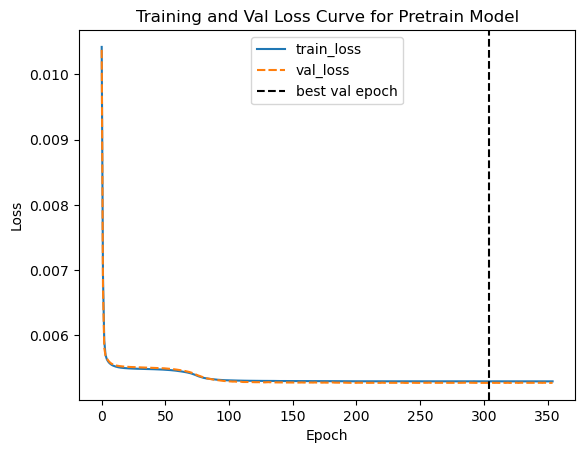

In [88]:
ax = plot_train_and_val_loss(np.array(pretrain_results), title="Training and Val Loss Curve for Pretrain Model")

In [ ]:
# Load best pretrain model
backbone = MDNBackbone(
    input_dim=X_train.shape[1],
    hidden_dim=16,
    hidden_layers=3,
    feature_dropout=0.05
)

pretrain_model = MDNPretrain(
    backbone=backbone
)

pretrain_model.load_state_dict(torch.load("../results/pretrain_model.pt", map_location="cpu"))

# Full training loop
train_data = TensorDataset(X_train, y_train)
val_data = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)

transfer_model_ret = MDNFinalLayer(backbone, n_components=5, mean_zero=False)

if transfer_model_ret.means is not None:
    # Initialize mean weights to 0
    torch.nn.init.zeros_(transfer_model_ret.means.weight)
    torch.nn.init.zeros_(transfer_model_ret.means.bias)
        
    # freeze backbone if I want
    for param in transfer_model_ret.backbone.parameters():
        param.requires_grad = True

    optimizer = torch.optim.Adam(
        [
            {"params": transfer_model_ret.backbone.parameters(), "lr": 2e-5},
            {"params": transfer_model_ret.mixture_weights.parameters(), "lr": 6e-5},
            {"params": transfer_model_ret.scales.parameters(), "lr": 6e-5},
            {"params": transfer_model_ret.means.parameters(), "lr": 4e-6},
        ]
    )

else:
    # Only exists to make pylint happy
    optimizer = torch.optim.Adam(transfer_model_ret.parameters(), lr=1e-5)


epochs = 500
early_stopping_patience = 50

transfer_results_ret = []
best_val_nll = np.inf
last_improvement = 0
best_state_dict = None

print_frequency = 20

for t in range(1, epochs + 1):
    epoch_loss = train_mdn(transfer_model_ret, train_loader, optimizer)
    epoch_val_nll = compute_mdn_nll(transfer_model_ret, val_loader)
    epoch_train_nll = compute_mdn_nll(transfer_model_ret, train_loader)
    epoch_val_crps = compute_mean_crps_mdn(transfer_model_ret, val_loader)

    if epoch_val_nll < best_val_nll:
        best_val_nll = epoch_val_nll
        last_improvement = t
        best_epoch = t
        best_state_dict = copy.deepcopy(transfer_model_ret.state_dict())

    if t % print_frequency == 0:
        print(f"Epoch {t}/{epochs}\n-------------------------------")
        print(f"Loss: {epoch_loss:.2f}, training nll: {epoch_train_nll}, val nll: {epoch_val_nll}, val crps: {epoch_val_crps}\n")

    transfer_results_ret.append([epoch_loss, epoch_train_nll, epoch_val_nll, epoch_val_crps])
    
    if t - last_improvement >= early_stopping_patience:
        break

best_idx = max(0, last_improvement - 1)

if best_state_dict is not None:
    transfer_model_ret.load_state_dict(best_state_dict)

transfer_results_ret = np.array(transfer_results_ret)
val_nlls = transfer_results_ret[:, 2]
left = max(0, best_idx - 10)
right = min(len(val_nlls), best_idx + 3)
local_mean_val_nll = float(np.mean(val_nlls[left:right]))
print(f"Best val nll: {best_val_nll}, local mean vall nll: {local_mean_val_nll:.6f}")

Epoch 20/500
-------------------------------
Loss: -3.95, training nll: -3.999689817428589, val nll: -4.190799713134766, val crps: 0.0020528195919445697

Epoch 40/500
-------------------------------
Loss: -4.26, training nll: -4.295430660247803, val nll: -4.4707183837890625, val crps: 0.0016965512743614302

Epoch 60/500
-------------------------------
Loss: -4.33, training nll: -4.365890026092529, val nll: -4.541558742523193, val crps: 0.0016329644380545262

Epoch 80/500
-------------------------------
Loss: -4.35, training nll: -4.3861870765686035, val nll: -4.55964994430542, val crps: 0.0016162451870409737

Epoch 100/500
-------------------------------
Loss: -4.36, training nll: -4.3916802406311035, val nll: -4.561554908752441, val crps: 0.0016130212239307492

Epoch 120/500
-------------------------------
Loss: -4.37, training nll: -4.396814346313477, val nll: -4.567212104797363, val crps: 0.0016105373982471568

Epoch 140/500
-------------------------------
Loss: -4.38, training nll:

In [80]:
torch.save(transfer_model_ret.state_dict(), "../results/transfer_model_ret.pt")

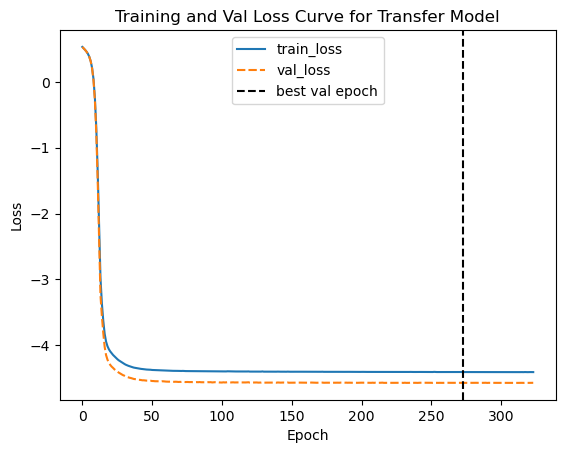

In [81]:
ax = plot_train_and_val_loss(np.array(transfer_results_ret), title="Training and Val Loss Curve for Transfer Model")

In [36]:
# Load best pretrain model
backbone = MDNBackbone(
    input_dim=X_train.shape[1],
    hidden_dim=16,
    hidden_layers=3,
    feature_dropout=0.05
)

pretrain_model = MDNPretrain(
    backbone=backbone
)

pretrain_model.load_state_dict(torch.load("../results/pretrain_model.pt", map_location="cpu"))

# Full training loop
train_data = TensorDataset(X_train, y_train)
val_data = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)

transfer_model_no_ret = MDNFinalLayer(backbone, n_components=5, mean_zero=True)
    
# freeze backbone if I want
for param in transfer_model_no_ret.backbone.parameters():
    param.requires_grad = True


optimizer = torch.optim.Adam(
    [
        {"params": transfer_model_no_ret.backbone.parameters(), "lr": 2e-5},
        {"params": transfer_model_no_ret.mixture_weights.parameters(), "lr": 6e-5},
        {"params": transfer_model_no_ret.scales.parameters(), "lr": 6e-5},
    ]
)

epochs = 500
early_stopping_patience = 50

transfer_results_no_ret = []
best_val_nll = np.inf
last_improvement = 0
best_state_dict = None

print_frequency = 20

for t in range(1, epochs + 1):
    epoch_loss = train_mdn(transfer_model_no_ret, train_loader, optimizer)
    epoch_val_nll = compute_mdn_nll(transfer_model_no_ret, val_loader)
    epoch_train_nll = compute_mdn_nll(transfer_model_no_ret, train_loader)
    epoch_val_crps = compute_mean_crps_mdn(transfer_model_no_ret, val_loader)

    if epoch_val_nll < best_val_nll:
        best_val_nll = epoch_val_nll
        last_improvement = t
        best_epoch = t
        best_state_dict = copy.deepcopy(transfer_model_no_ret.state_dict())

    if t % print_frequency == 0:
        print(f"Epoch {t}/{epochs}\n-------------------------------")
        print(f"Loss: {epoch_loss:.2f}, training nll: {epoch_train_nll}, val nll: {epoch_val_nll}, val crps: {epoch_val_crps}\n")

    transfer_results_no_ret.append([epoch_loss, epoch_train_nll, epoch_val_nll, epoch_val_crps])
    
    if t - last_improvement >= early_stopping_patience:
        break

best_idx = max(0, last_improvement - 1)

if best_state_dict is not None:
    transfer_model_no_ret.load_state_dict(best_state_dict)

transfer_results_no_ret = np.array(transfer_results_no_ret)
val_nlls = transfer_results_no_ret[:, 2]
left = max(0, best_idx - 10)
right = min(len(val_nlls), best_idx + 3)
local_mean_val_nll = float(np.mean(val_nlls[left:right]))
print(f"Best val nll: {best_val_nll}, local mean vall nll: {local_mean_val_nll:.6f}")

Epoch 20/500
-------------------------------
Loss: -3.01, training nll: -3.064465045928955, val nll: -3.1243793964385986, val crps: 0.01438018997544654

Epoch 40/500
-------------------------------
Loss: -4.29, training nll: -4.343640327453613, val nll: -4.5109148025512695, val crps: 0.0016526246727761615

Epoch 60/500
-------------------------------
Loss: -4.35, training nll: -4.387805461883545, val nll: -4.555423259735107, val crps: 0.0016183789476036177

Epoch 80/500
-------------------------------
Loss: -4.36, training nll: -4.39522123336792, val nll: -4.563238143920898, val crps: 0.0016131150739969852

Epoch 100/500
-------------------------------
Loss: -4.37, training nll: -4.396703720092773, val nll: -4.563492774963379, val crps: 0.0016121006280933653

Epoch 120/500
-------------------------------
Loss: -4.38, training nll: -4.398316860198975, val nll: -4.565786361694336, val crps: 0.0016109912544596725

Epoch 140/500
-------------------------------
Loss: -4.38, training nll: -4

In [37]:
torch.save(transfer_model_no_ret.state_dict(), "../results/transfer_model_no_ret.pt")

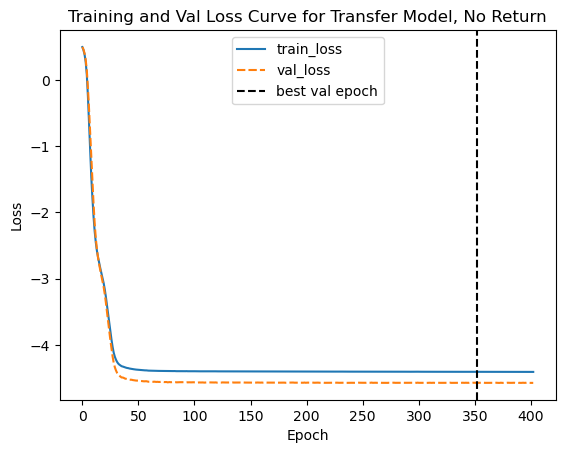

In [40]:
ax = plot_train_and_val_loss(np.array(transfer_results_no_ret), title="Training and Val Loss Curve for Transfer Model, No Return")

# Compare Models

In [82]:
backbone_ret = MDNBackbone(
    input_dim=X_train.shape[1],
    hidden_dim=16,
    hidden_layers=3,
    dropout=0.0,
    feature_dropout=0.1,
)

backbone_no_ret = MDNBackbone(
    input_dim=X_train.shape[1],
    hidden_dim=16,
    hidden_layers=3,
    dropout=0.0,
    feature_dropout=0.1,
)

transfer_model_ret = MDNFinalLayer(backbone_ret, n_components=5, mean_zero=False)
transfer_model_ret.load_state_dict(torch.load("../results/transfer_model_ret.pt", map_location="cpu"))

transfer_model_no_ret = MDNFinalLayer(backbone_no_ret, n_components=5, mean_zero=True)
transfer_model_no_ret.load_state_dict(torch.load("../results/transfer_model_no_ret.pt", map_location="cpu"))

original_model = MDN(
    input_dim=X_train.shape[1],
    hidden_dim=16,
    n_components=5,
    hidden_layers=3,
    feature_dropout=0.1,
    mean_zero=True
)
original_model.load_state_dict(torch.load("../results/original_model.pt", map_location="cpu"))

<All keys matched successfully>

In [83]:
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

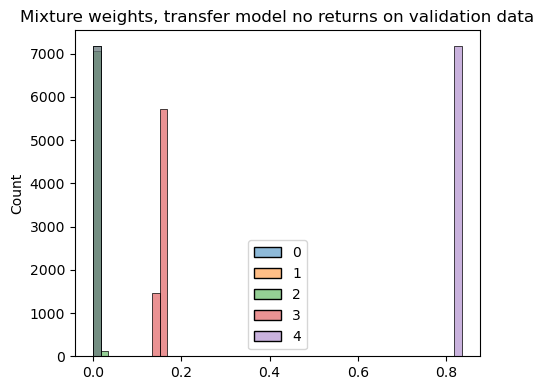

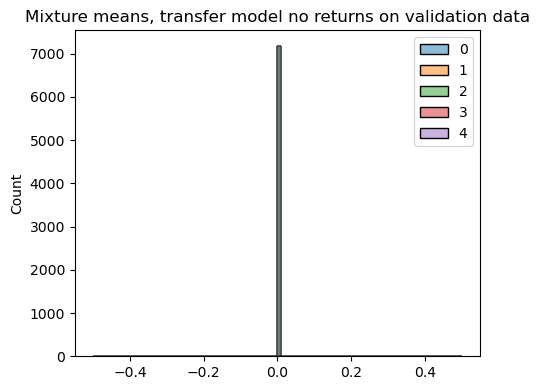

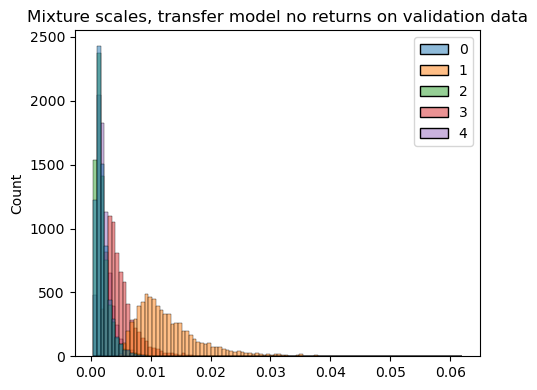

In [84]:
ax1, ax2, ax3 = plot_predicted_parameters(transfer_model_no_ret, "transfer model no returns", val_loader, "validation")

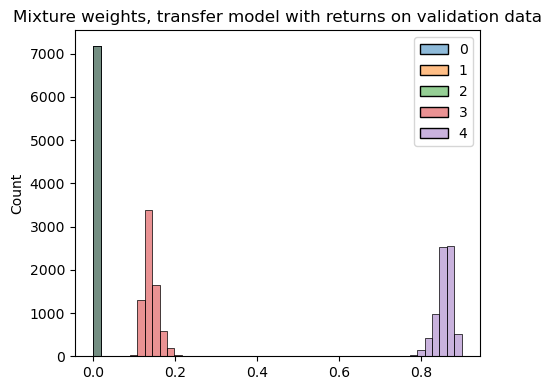

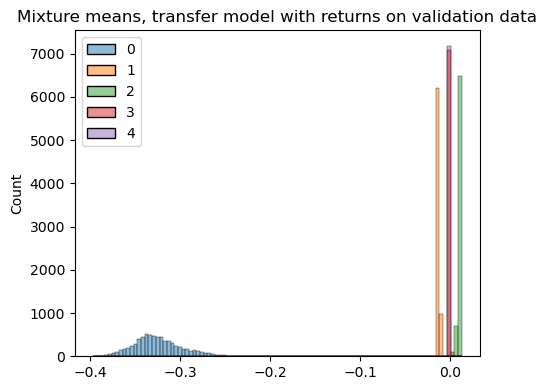

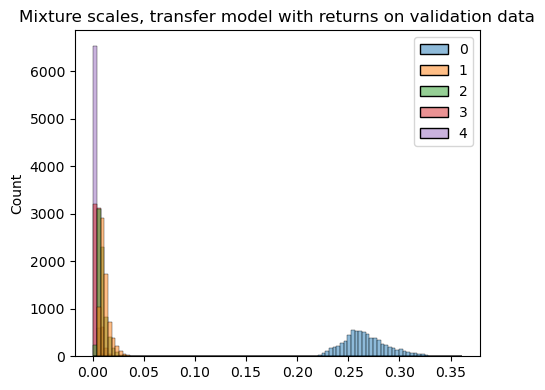

In [85]:
ax1, ax2, ax3 = plot_predicted_parameters(transfer_model_ret, "transfer model with returns", val_loader, "validation")


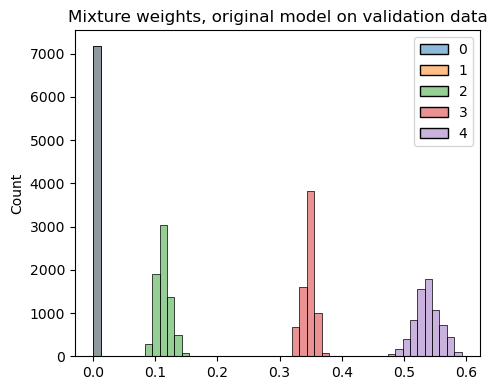

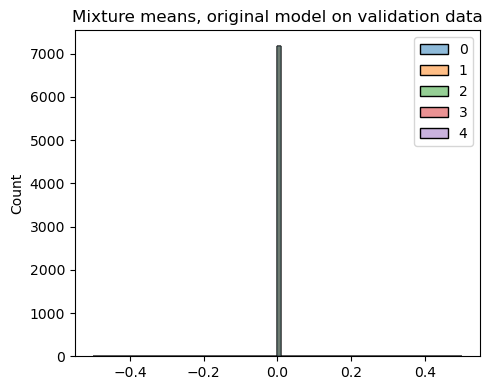

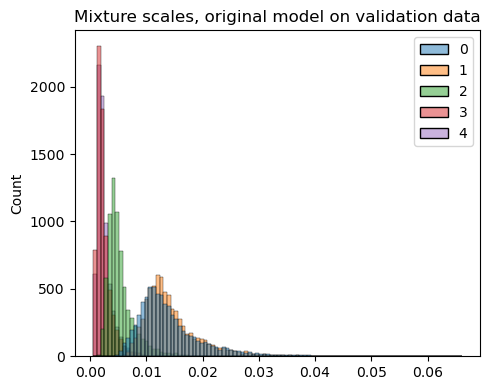

In [45]:
ax1, ax2, ax3 = plot_predicted_parameters(original_model, "original model", val_loader, "validation", save_figs=True)


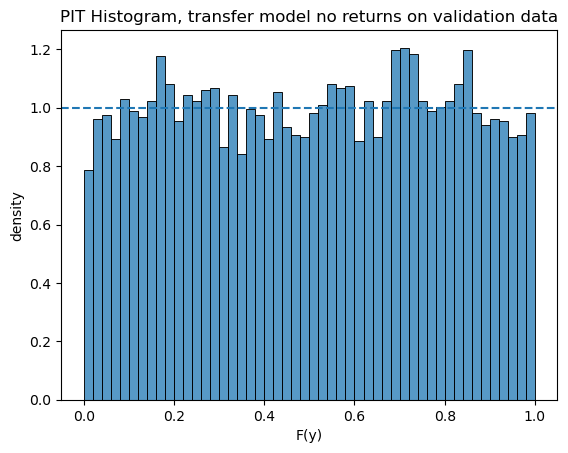

In [46]:
ax = plot_pit(transfer_model_no_ret, "transfer model no returns", val_loader, "validation")


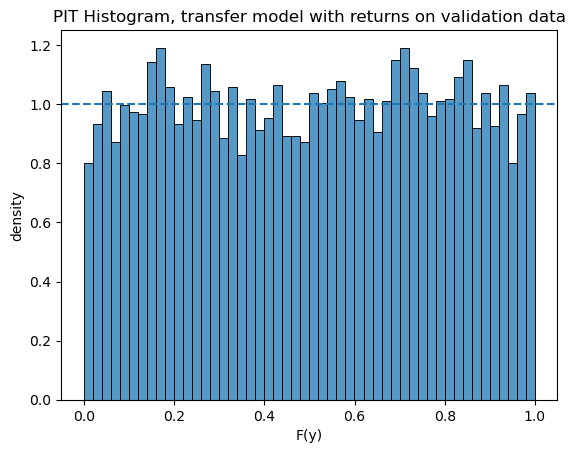

In [47]:
ax = plot_pit(transfer_model_ret, "transfer model with returns", val_loader, "validation")


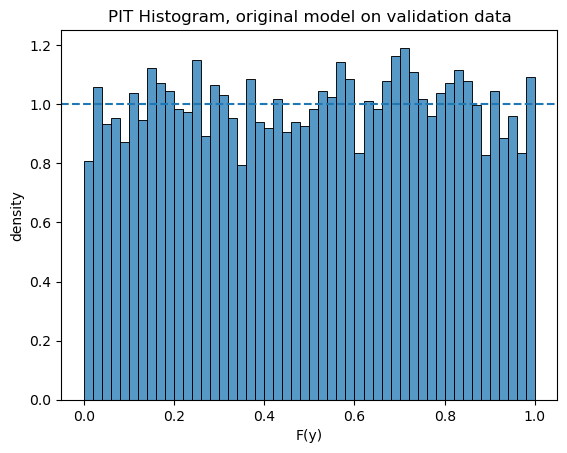

In [48]:
ax = plot_pit(original_model, "original model", val_loader, "validation")


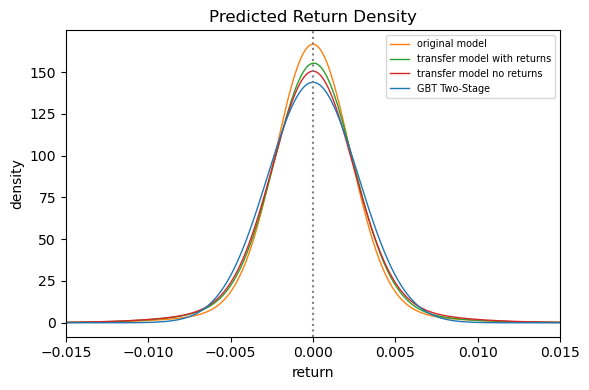

In [49]:
ax = plot_mdns_vs_gbt_vol_medoid(
    X_val,
    {"original model": original_model,
     "transfer model with returns": transfer_model_ret,
     "transfer model no returns": transfer_model_no_ret},
    df_val,
    left=-0.015,
    right=0.015,
)

### Trading Simulation

In [50]:
def price_call_mixture(strike_return, mixture_probs, means, scales):
    z = (means - strike_return) / scales
    individual_prices = (means - strike_return) * stats.norm.cdf(z) + scales * stats.norm.pdf(z)
    return torch.sum(mixture_probs * individual_prices, dim=1)

def price_binary_mixture(strike_return, mixture_probs, means, scales):
    z = (means - strike_return) / scales
    individual_prices = stats.norm.cdf(z)
    return torch.sum(mixture_probs * individual_prices, dim=1)

def simulate_call_trades_mdn(strike_return, model_one, model_two, X, y, tol=1e-5):
    model_one.eval() 
    model_two.eval()
    with torch.no_grad():
        X, y = X.to(device), y.to(device)
        
        mixture_probs, means, scales = model_one(X)
        prices_one = price_call_mixture(strike_return, mixture_probs, means, scales)

        mixture_probs, means, scales = model_two(X)
        prices_two = price_call_mixture(strike_return, mixture_probs, means, scales)

        trade_price = 0.5 * (prices_one + prices_two)

        payoff = torch.maximum(y - strike_return, torch.zeros_like(y))

        direction = torch.where(torch.abs(prices_one - prices_two) < tol, 0, torch.where(prices_one < prices_two, -1, 1))

        return direction * (payoff - trade_price)
    
def simulate_binary_trades_mdn(strike_return, model_one, model_two, X, y, tol=1e-5):
    model_one.eval() 
    model_two.eval()
    with torch.no_grad():
        X, y = X.to(device), y.to(device)
        
        mixture_probs, means, scales = model_one(X)
        prices_one = price_binary_mixture(strike_return, mixture_probs, means, scales)

        mixture_probs, means, scales = model_two(X)
        prices_two = price_binary_mixture(strike_return, mixture_probs, means, scales)

        trade_price = 0.5 * (prices_one + prices_two)

        payoff = torch.where(y > strike_return, 1, 0)

        direction = torch.where(torch.abs(prices_one - prices_two) < tol, 0, torch.where(prices_one < prices_two, -1, 1))

        return direction * (payoff - trade_price)
    

def price_call_normal(sigma: float, strike_return: float, mu: float = 0.0):
    z = (mu - strike_return) / sigma
    return np.where(sigma > 0, (mu - strike_return) * stats.norm.cdf(z) + sigma * stats.norm.pdf(z), max(mu - strike_return, 0.0))

def price_binary_normal(sigma: float, strike_return: float, mu: float = 0.0):
    z = (mu - strike_return) / sigma
    return np.where(sigma > 0, stats.norm.cdf(z), np.where(mu - strike_return > 0, 1, 0))


def simulate_call_trades_mdn_vs_gbt(strike_return, model, X, y, df, tol=1e-5):
    pnls = []

    model.eval() 
    with torch.no_grad():
        X, y = X.to(device), y.to(device)
        
        mixture_probs, means, scales = model(X)
        prices_mdn = price_call_mixture(strike_return, mixture_probs, means, scales)

        gbt_sigma = np.sqrt(df["gbt_future_30m_mean_sq_ret_pred"] * 30).reset_index(drop=True)
        prices_gbt = torch.tensor(price_call_normal(gbt_sigma, strike_return))

        trade_price = 0.5 * (prices_mdn + prices_gbt)

        payoff = torch.maximum(y - strike_return, torch.zeros_like(y))

        direction = torch.where(torch.abs(prices_mdn - prices_gbt) < tol, 0, torch.where(prices_mdn < prices_gbt, -1, 1))

        pnls.append(direction * (payoff - trade_price))


    return torch.cat(pnls).numpy()

def simulate_binary_trades_mdn_vs_gbt(strike_return, model, X, y, df, tol=1e-5):
    pnls = []

    model.eval() 
    with torch.no_grad():
        X, y = X.to(device), y.to(device)
        
        mixture_probs, means, scales = model(X)
        prices_mdn = price_binary_mixture(strike_return, mixture_probs, means, scales)

        gbt_sigma = np.sqrt(df["gbt_future_30m_mean_sq_ret_pred"] * 30).reset_index(drop=True)
        prices_gbt = torch.tensor(price_binary_normal(gbt_sigma, strike_return))

        trade_price = 0.5 * (prices_mdn + prices_gbt)

        payoff = torch.where(y > strike_return, 1, 0)

        direction = torch.where(torch.abs(prices_mdn - prices_gbt) < tol, 0, torch.where(prices_mdn < prices_gbt, -1, 1))

        pnls.append(direction * (payoff - trade_price))


    return torch.cat(pnls).numpy()

def compute_pricing_error_mdn(strike_return, model, X, y):
    errors = []

    model.eval() 
    with torch.no_grad():
        X, y = X.to(device), y.to(device)
        
        mixture_probs, means, scales = model(X)
        prices_mdn = price_call_mixture(strike_return, mixture_probs, means, scales)

        payoff = torch.maximum(y - strike_return, torch.zeros_like(y))

        error = payoff - prices_mdn

        errors.append(error)


    return torch.cat(errors).numpy()

def compute_pricing_error_gbt(strike_return, y, df):
    errors = []

    gbt_sigma = np.sqrt(df["gbt_future_30m_mean_sq_ret_pred"] * 30).reset_index(drop=True)
    prices_gbt = torch.tensor(price_call_normal(gbt_sigma, strike_return))

    payoff = torch.maximum(y - strike_return, torch.zeros_like(y))

    error = payoff - prices_gbt

    errors.append(error)


    return torch.cat(errors).numpy()

# def simulate_call_trades_mdn_vs_gbt(strike_return, model, model_two, data_loader, df):
#     pnls = []

#     model_one.eval() 
#     model_two.eval()
#     with torch.no_grad():
#         for (X, y) in data_loader:
#             X, y = X.to(device), y.to(device)
            
#             mixture_weights, means, scales = model_one(X)
#             mixture_probs = F.softmax(mixture_weights, dim=1)
#             prices_one = price_call_mixture(strike_return, mixture_probs, means, scales)

#             mixture_weights, means, scales = model_two(X)
#             mixture_probs = F.softmax(mixture_weights, dim=1)
#             prices_two = price_call_mixture(strike_return, mixture_probs, means, scales)

#             trade_price = 0.5 * (prices_one + prices_two)

#             payoff = torch.maximum(y - strike_return, torch.zeros_like(y))

#             direction = torch.where(prices_one < prices_two, -1, 1)

#             pnls.append(direction * (payoff - trade_price))


#     return torch.cat(pnls).numpy()



<Axes: >

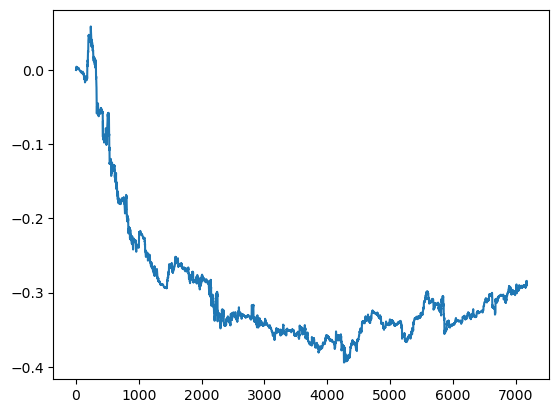

In [51]:
pnls = simulate_call_trades_mdn(0.001, original_model, transfer_model_no_ret, X_val, y_val, tol=1e-5)
sns.lineplot(np.cumsum(pnls))

<Axes: >

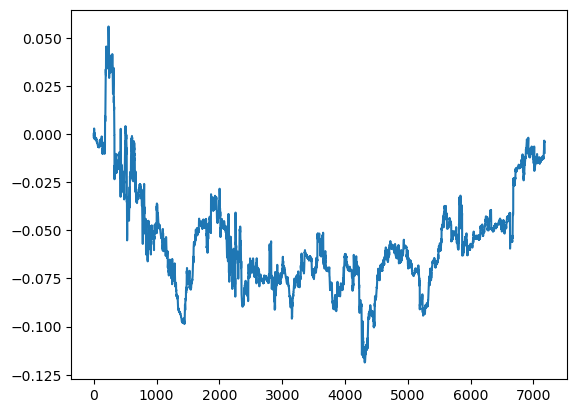

In [52]:
pnls = simulate_call_trades_mdn(0.001, original_model, transfer_model_ret, X_val, y_val)
sns.lineplot(np.cumsum(pnls))

<Axes: >

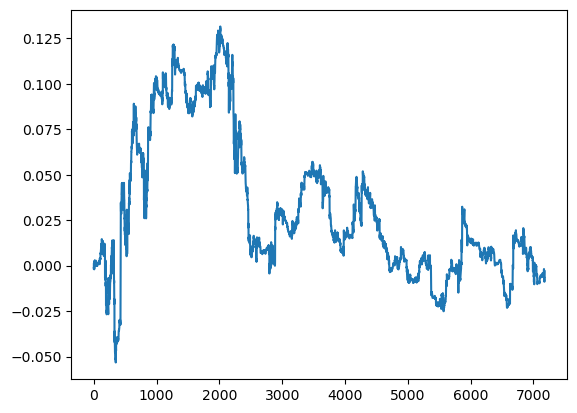

In [53]:
pnls = simulate_call_trades_mdn(0.001, transfer_model_no_ret, transfer_model_ret, X_val, y_val)
sns.lineplot(np.cumsum(pnls))

<Axes: >

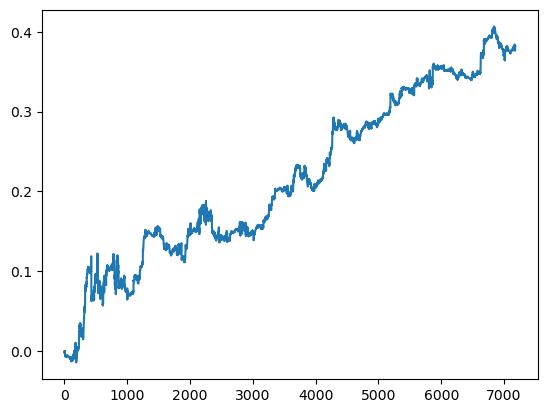

In [55]:
pnls = simulate_call_trades_mdn_vs_gbt(0.001, transfer_model_no_ret, X_val, y_val, df_val)
sns.lineplot(np.cumsum(pnls))

<Axes: >

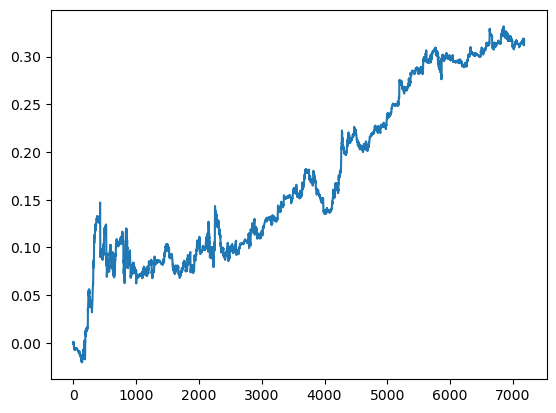

In [56]:
pnls = simulate_call_trades_mdn_vs_gbt(0.001, transfer_model_ret, X_val, y_val, df_val)
sns.lineplot(np.cumsum(pnls))

<Axes: >

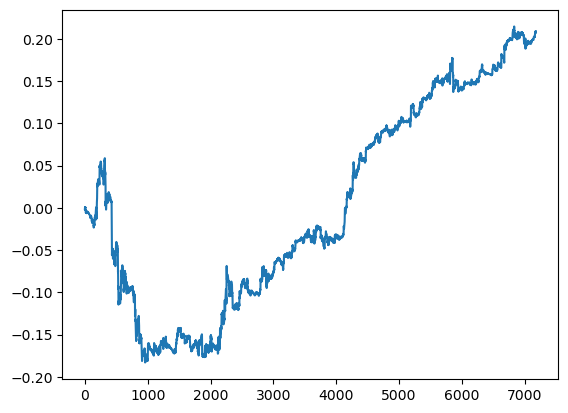

In [57]:
pnls = simulate_call_trades_mdn_vs_gbt(0.001, original_model, X_val, y_val, df_val)
sns.lineplot(np.cumsum(pnls))

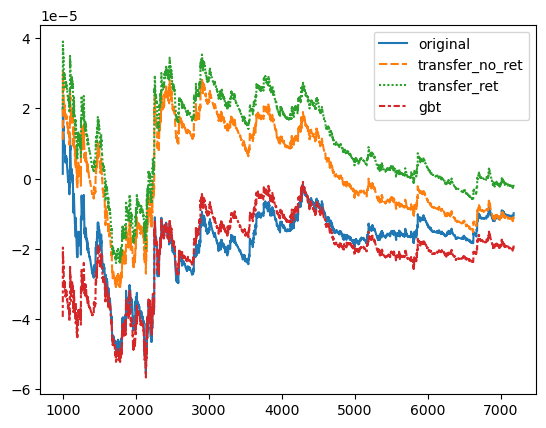

In [59]:
def plot_average_error(errors: dict, min_points):
    df = pd.DataFrame({col: np.cumsum(error) / np.cumsum(np.ones_like(error)) for col, error in errors.items()})
    sns.lineplot(df[min_points:])

error_original = compute_pricing_error_mdn(0.001, original_model, X_val, y_val)
error_transfer_no_ret = compute_pricing_error_mdn(0.001, transfer_model_no_ret, X_val, y_val)
error_transfer_ret = compute_pricing_error_mdn(0.001, transfer_model_ret, X_val, y_val)
error_gbt = compute_pricing_error_gbt(0.001, y_val, df_val)
plot_average_error({"original": error_original, "transfer_no_ret": error_transfer_no_ret,
                    "transfer_ret": error_transfer_ret, "gbt": error_gbt}, 
                    1000)

<Axes: >

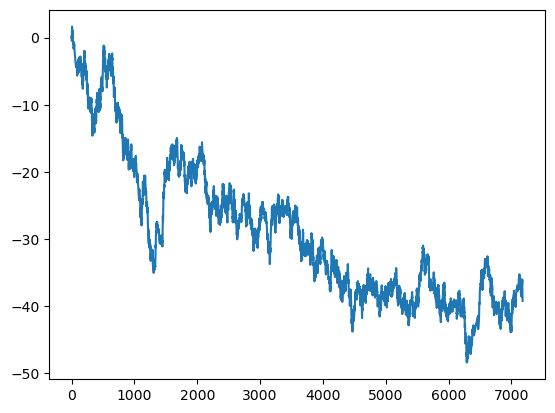

In [65]:
pnls = simulate_binary_trades_mdn(0.0016, original_model, transfer_model_no_ret, X_val, y_val, tol=1e-5)
sns.lineplot(np.cumsum(pnls))

<Axes: >

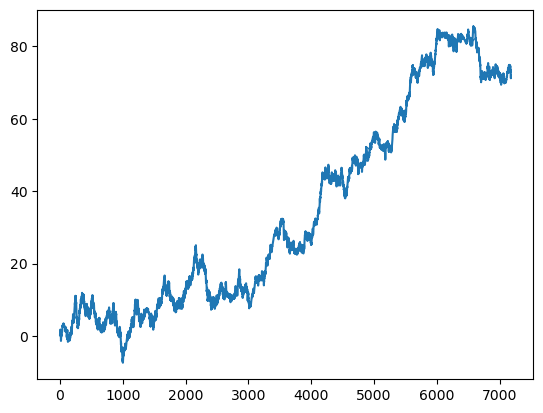

In [74]:
pnls = simulate_binary_trades_mdn_vs_gbt(0.0016, transfer_model_ret, X_val, y_val, df_val)
sns.lineplot(np.cumsum(pnls))

In [76]:
df["future_30m_ret"].quantile(0.75)

0.0015851441234372432

<Axes: ylabel='open'>

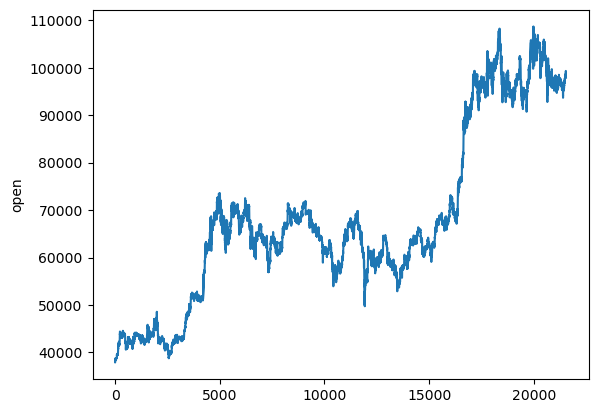

In [77]:
sns.lineplot(downsample(df_train, set([0, 30])).reset_index(drop=True)["open"])

In [78]:
print(original_model)

MDN(
  (net): Sequential(
    (feature_dropout): Dropout(p=0.1, inplace=False)
    (input): Linear(in_features=90, out_features=16, bias=True)
    (relu_input): ReLU()
    (dropout_input): Dropout(p=0.0, inplace=False)
    (linear0): Linear(in_features=16, out_features=16, bias=True)
    (relu0): ReLU()
    (dropout0): Dropout(p=0.0, inplace=False)
    (linear1): Linear(in_features=16, out_features=16, bias=True)
    (relu1): ReLU()
    (dropout1): Dropout(p=0.0, inplace=False)
    (linear2): Linear(in_features=16, out_features=16, bias=True)
    (relu2): ReLU()
    (dropout2): Dropout(p=0.0, inplace=False)
  )
  (mixture_weights): Linear(in_features=16, out_features=5, bias=True)
  (scales): Linear(in_features=16, out_features=5, bias=True)
)


In [81]:
def calculate_normal_nll(y, sigma, min_sigma=1e-12):
    """
    Calculate negative log-likelihood from returns and 
    scale parameters.
    """
    sigma = np.clip(sigma, min_sigma, None)
    return np.mean(
        0.5 * np.log(2 * np.pi)
        + np.log(sigma)
        + 0.5 * (y / sigma) ** 2
    )

def gaussian_crps(returns, sigma):
    """
    CRPS for N(0, sigma^2) predictions.
    returns : array of realized returns
    sigma   : array of predicted std deviations
    """
    z = returns / sigma
    crps = sigma * (
        z * (2 * stats.norm.cdf(z) - 1)
        + 2 * stats.norm.pdf(z)
        - 1 / np.sqrt(np.pi)
    )
    return np.mean(crps)

In [82]:
test_data = TensorDataset(X_test, y_test)
test_loader = DataLoader(val_data, batch_size=128, shuffle=False)

gbt_sigma = np.sqrt(df_val["gbt_future_30m_mean_sq_ret_pred"] * 30).reset_index(drop=True)

original_nll = compute_nll(original_model, test_loader)
transfer_no_ret_nll = compute_nll(transfer_model_no_ret, test_loader)
transfer_ret_nll = compute_nll(transfer_model_ret, test_loader)
gbt_nll = calculate_normal_nll(y_val.numpy(), gbt_sigma)

original_crps = compute_crps(original_model, test_loader)
transfer_no_ret_crps = compute_crps(transfer_model_no_ret, test_loader)
transfer_ret_crps = compute_crps(transfer_model_ret, test_loader)
gbt_crps = gaussian_crps(y_val.numpy(), gbt_sigma)

NameError: name 'compute_nll' is not defined

In [80]:
results = pd.DataFrame({
    "Model": [
        "Baseline Normal (GBT Volatility)",
        "MDN (No Transfer, No Mean Prediction)",
        "MDN (Transfer, No Mean Prediction)",
        "MDN (Transfer, With Mean Prediction)"
    ],
    "NLL": [
        float(gbt_nll),
        original_nll.item(),
        transfer_no_ret_nll.item(),
        transfer_ret_nll.item()
    ],
    "CRPS": [
        float(gbt_crps),
        float(original_crps),
        float(transfer_no_ret_crps),
        float(transfer_ret_crps)
    ]
})

print(results.round({"NLL": 4, "CRPS": 8}).to_latex(index=False))

NameError: name 'gbt_nll' is not defined

In [42]:
results

,Model,NLL,CRPS
0,Baseline Normal (GBT Volatility),-4.508381,0.001613
1,"MDN (No Transfer, No Mean Prediction)",-4.571355,0.001610
2,"MDN (Transfer, No Mean Prediction)",-4.573061,0.001608
3,"MDN (Transfer, With Mean Prediction)",-4.574255,0.001608


In [43]:
results

,Model,NLL,CRPS
0,Baseline Normal (GBT Volatility),-4.508381,0.001613
1,"MDN (No Transfer, No Mean Prediction)",-4.571355,0.001610
2,"MDN (Transfer, No Mean Prediction)",-4.573061,0.001608
3,"MDN (Transfer, With Mean Prediction)",-4.574255,0.001608


In [44]:
def compute_prob_up_mdn(model, X, y):
    model.eval() 
    with torch.no_grad():
        X, y = X.to(device), y.to(device)
        
        mixture_weights, means, scales = model(X)
        mixture_probs = F.softmax(mixture_weights, dim=1)
        p_below = price_binary_mixture(0.0, mixture_probs, means, scales)

        return p_below
    

In [55]:
torch.quantile(compute_prob_up_mdn(transfer_model_no_ret, X_val, y_val), 0.1)

tensor(0.5000, dtype=torch.float64)

In [117]:
df_val["pred_p_up"] = compute_prob_up_mdn(transfer_model_ret, X_val, y_val)

In [118]:
df_val["pred_p_up"].describe()

count    7179.000000
mean        0.496878
std         0.024194
min         0.357710
25%         0.481984
50%         0.500546
75%         0.514735
max         0.557379
Name: pred_p_up, dtype: float64

<Axes: ylabel='pred_p_up'>

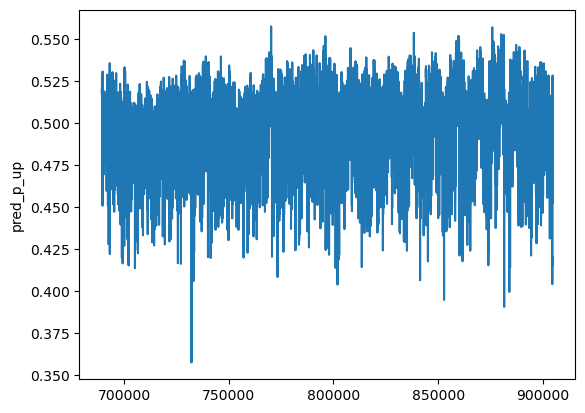

In [119]:
sns.lineplot(df_val["pred_p_up"])

In [120]:
df_val["up"] = np.where(df_val["future_30m_ret"] > 0, 1, 0)

<Axes: xlabel='pred_p_up', ylabel='Count'>

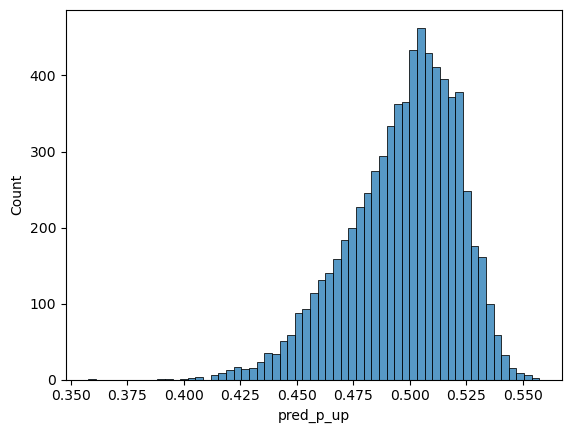

In [123]:
sns.histplot(df_val["pred_p_up"])

In [41]:
df_val.query("pred_p_up > 0.43 and pred_p_up < 0.45")[["pred_p_up", "up"]].describe()

UndefinedVariableError: name 'pred_p_up' is not defined

In [131]:
df_val.query("pred_p_up > 0.43 and pred_p_up < 0.45")

,split,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,...,future_15m_mean_sq_ret,future_30m_mean_sq_ret,future_30m_neutral_up_down,past_5m_abs_ret,past_30m_abs_ret,past_60m_abs_ret,past_120m_abs_ret,day_of_week,pred_p_up,up
692670,val,2025-02-23 19:30:00 ET,96408.60,96409.70,96363.76,96363.76,4.48057,2025-02-23 19:30:59 ET,4.318811e+05,1299,...,2.129888e-07,1.979150e-07,0,0.000189,0.001565,0.005783,0.008297,6,0.438177,0
695310,val,2025-02-25 15:30:00 ET,88680.59,88714.41,88568.33,88653.93,80.73302,2025-02-25 15:30:59 ET,7.156900e+06,4679,...,1.290405e-06,9.696694e-07,0,0.001000,0.008339,0.020507,0.019981,1,0.447229,0
697620,val,2025-02-27 06:00:00 ET,87013.47,87078.46,86988.93,86988.93,45.91997,2025-02-27 06:00:59 ET,3.996716e+06,8524,...,4.523456e-07,5.026510e-07,0,0.002725,0.007081,0.009791,0.010862,3,0.447960,0
698340,val,2025-02-27 18:00:00 ET,84716.01,84735.85,84523.80,84534.92,52.75063,2025-02-27 18:00:59 ET,4.464433e+06,12738,...,5.524216e-07,4.251487e-07,0,0.003060,0.008020,0.003635,0.014296,3,0.439660,0
699090,val,2025-02-28 06:30:00 ET,80616.68,80631.69,80520.65,80522.36,20.16138,2025-02-28 06:30:59 ET,1.624398e+06,5346,...,9.127143e-07,8.834786e-07,0,0.002137,0.007570,0.008293,0.002456,4,0.446976,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
897060,val,2025-07-15 19:00:00 ET,117827.74,117955.00,117827.73,117926.00,47.27773,2025-07-15 19:00:59 ET,5.574122e+06,3218,...,1.262482e-07,1.507270e-07,0,0.000388,0.002553,0.002329,0.012101,1,0.447512,0
897690,val,2025-07-16 05:30:00 ET,119141.43,119154.01,119141.43,119146.14,5.79777,2025-07-16 05:30:59 ET,6.908131e+05,774,...,9.112758e-08,2.375566e-07,1,0.001188,0.003719,0.007702,0.007573,2,0.439956,1
899130,val,2025-07-17 05:30:00 ET,119135.92,119140.00,119054.16,119125.99,23.40397,2025-07-17 05:30:59 ET,2.787650e+06,3337,...,2.614481e-07,1.743416e-07,0,0.002283,0.006803,0.007381,0.010202,3,0.439194,0
899850,val,2025-07-17 17:30:00 ET,120899.36,120915.75,120715.03,120824.20,25.68774,2025-07-17 17:30:59 ET,3.103577e+06,5018,...,1.303729e-06,1.090995e-06,0,0.000151,0.012245,0.015624,0.010390,3,0.446570,0


In [ ]:
sns.histplot(df_val["pred_p_up"])

(-25566.416666666668, -25566.25)

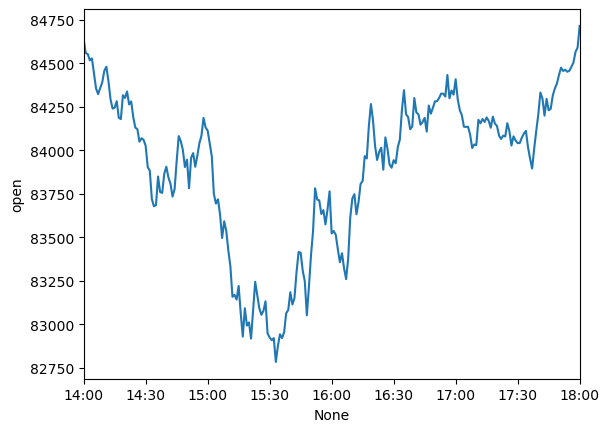

In [141]:
import matplotlib.dates as mdates

to_plot = df[(df["open_time"] <= "2025-02-27 18:00:00 ET") & (df["open_time"] >= "2025-02-27 14:00:00 ET")]

time = pd.to_datetime(
    to_plot["hour"].astype(str) + ":" + to_plot["minute"].astype(str),
    format="%H:%M"
)


ax = sns.lineplot(x=time, y=to_plot["open"])

ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlim(time.iloc[0], time.iloc[-1])